# Structure vs Function — Network Comparison (Synapse Count)

Compares the **functional network** (93×93 Pearson correlation matrix, session 9.3 V1) with the **count-weighted structural network** (same 93 neurons; edge weight = number of synapses per pair).

Counterpart of `compare_structural_functional.ipynb` which uses synaptic cleft size as edge weight; this version uses synapse count instead.

Key questions:
- Are directly connected neurons more functionally correlated?
- Does the **number of synapses** between two neurons predict functional similarity?
- Do connected neurons share orientation tuning preferences?
- Are hub neurons in the structural network also hubs functionally?
- Do both networks share the same topology?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Data

In [2]:
# Functional matrix lives in the root outputs/ folder.
F           = np.load('outputs/functional_network/F_correlation_matrix.npy')
func_cohort = pd.read_csv('outputs/functional_network/functional_cohort.csv')

# Count-weighted structural exports (created by visualize_structural-Leo.ipynb).
s_nodes = pd.read_csv('data/exports/G_93_count_nodes.csv')
s_edges = pd.read_csv('data/exports/G_93_count_edges.csv')

s_nodes_906 = pd.read_csv('data/exports/G_906_count_nodes.csv')
s_edges_906 = pd.read_csv('data/exports/G_906_count_edges.csv')

print(f'Functional matrix shape : {F.shape}')
print(f'Functional cohort       : {func_cohort.shape}')
print(f'Structural nodes (93)   : {s_nodes.shape}')
print(f'Structural edges (93)   : {s_edges.shape}')
print(f'Structural nodes (906)  : {s_nodes_906.shape}')
print(f'Structural edges (906)  : {s_edges_906.shape}')
print(f'\nF diagonal (should all be 1.0): {np.unique(np.diag(F))}')

Functional matrix shape : (93, 93)
Functional cohort       : (93, 16)
Structural nodes (93)   : (93, 13)
Structural edges (93)   : (229, 3)
Structural nodes (906)  : (906, 13)
Structural edges (906)  : (11822, 3)

F diagonal (should all be 1.0): [1. 1. 1.]


---
## 2. Merge Structural + Functional into One Table

In [3]:
merged = func_cohort.merge(
    s_nodes[['neuron_id', 'pref_ori', 'gOSI',
             'out_degree', 'in_degree', 'out_strength', 'in_strength']],
    left_on='pt_root_id', right_on='neuron_id',
    how='inner'
).reset_index(drop=True)

print(f'Merged table: {merged.shape} rows x cols')
print(f'Columns: {merged.columns.tolist()}')
assert len(merged) == 93, 'Expected 93 neurons after merge!'

id2midx = dict(zip(merged['pt_root_id'], merged['matrix_index']))

s_edges['pre_neuron_id']  = s_edges['pre_neuron_id'].astype('int64')
s_edges['post_neuron_id'] = s_edges['post_neuron_id'].astype('int64')
conn_set = set(zip(s_edges['pre_neuron_id'], s_edges['post_neuron_id']))
print(f'Structural connected pairs (directed): {len(conn_set)}')

Merged table: (93, 23) rows x cols
Columns: ['matrix_index', 'nucleus_id', 'pt_root_id', 'classification_system', 'cell_type', 'layer', 'brain_area', 'strategy_axon', 'strategy_dendrite', 'pt_position_x', 'pt_position_y', 'pt_position_z', 'session', 'scan_idx', 'unit_id', 'cc_abs', 'neuron_id', 'pref_ori', 'gOSI', 'out_degree', 'in_degree', 'out_strength', 'in_strength']
Structural connected pairs (directed): 229


---
## 3. Build All-Pairs Table

For every unordered pair of neurons (i, j) compute:
- `f_corr` — Pearson correlation from the functional matrix
- `conn_type` — `none` / `unidirectional` / `bidirectional`
- `n_synapses` — max synapse count between i→j and j→i (NaN if neither direction connects)
- `total_synapses` — sum of synapse counts in both directions
- `dist_um` — 3-D Euclidean distance in µm
- `ori_sim` — orientation tuning similarity cos(2·Δθ)

In [4]:
neurons = merged['pt_root_id'].values.astype('int64')
midxs   = merged['matrix_index'].values
xs = merged['pt_position_x'].values
ys = merged['pt_position_y'].values
zs = merged['pt_position_z'].values
thetas = merged['pref_ori'].values

# (pre, post) -> n_synapses
syn_n = dict(zip(zip(s_edges['pre_neuron_id'], s_edges['post_neuron_id']),
                 s_edges['n_synapses']))

rows = []
n = len(neurons)
for i in range(n):
    for j in range(i + 1, n):
        ni, nj = int(neurons[i]), int(neurons[j])
        fij = float(F[midxs[i], midxs[j]])
        c_ij = (ni, nj) in conn_set
        c_ji = (nj, ni) in conn_set
        if c_ij and c_ji:
            ctype = 'bidirectional'
        elif c_ij or c_ji:
            ctype = 'unidirectional'
        else:
            ctype = 'none'
        n_ij = syn_n.get((ni, nj), 0)
        n_ji = syn_n.get((nj, ni), 0)
        max_n   = max(n_ij, n_ji) if (c_ij or c_ji) else np.nan
        total_n = (n_ij + n_ji) if (c_ij or c_ji) else np.nan
        dist = np.sqrt((xs[i]-xs[j])**2 + (ys[i]-ys[j])**2 + (zs[i]-zs[j])**2)
        ori_sim = np.cos(2 * np.deg2rad(thetas[i] - thetas[j]))
        rows.append({'ni': ni, 'nj': nj,
                     'f_corr': fij,
                     'conn_type': ctype,
                     'connected': ctype != 'none',
                     'n_ij': n_ij, 'n_ji': n_ji,
                     'n_synapses': max_n,
                     'total_synapses': total_n,
                     'dist_um': dist,
                     'ori_sim': ori_sim})

pairs = pd.DataFrame(rows)
print(f'Total pairs:         {len(pairs):,}')
print(f'Connected pairs:     {pairs["connected"].sum():,}')
print(f'  unidirectional:    {(pairs["conn_type"]=="unidirectional").sum():,}')
print(f'  bidirectional:     {(pairs["conn_type"]=="bidirectional").sum():,}')
print(f'Unconnected pairs:   {(~pairs["connected"]).sum():,}')
print(f'\nFunctional correlation stats (all pairs):')
print(f'  mean={pairs["f_corr"].mean():.4f}  std={pairs["f_corr"].std():.4f}  '
      f'min={pairs["f_corr"].min():.4f}  max={pairs["f_corr"].max():.4f}')

Total pairs:         4,278
Connected pairs:     221
  unidirectional:    213
  bidirectional:     8
Unconnected pairs:   4,057

Functional correlation stats (all pairs):
  mean=0.0198  std=0.0367  min=-0.0306  max=0.6280


---
## Analysis 1 — Functional Correlation Distribution

Baseline look at what the correlation values look like across all pairs.

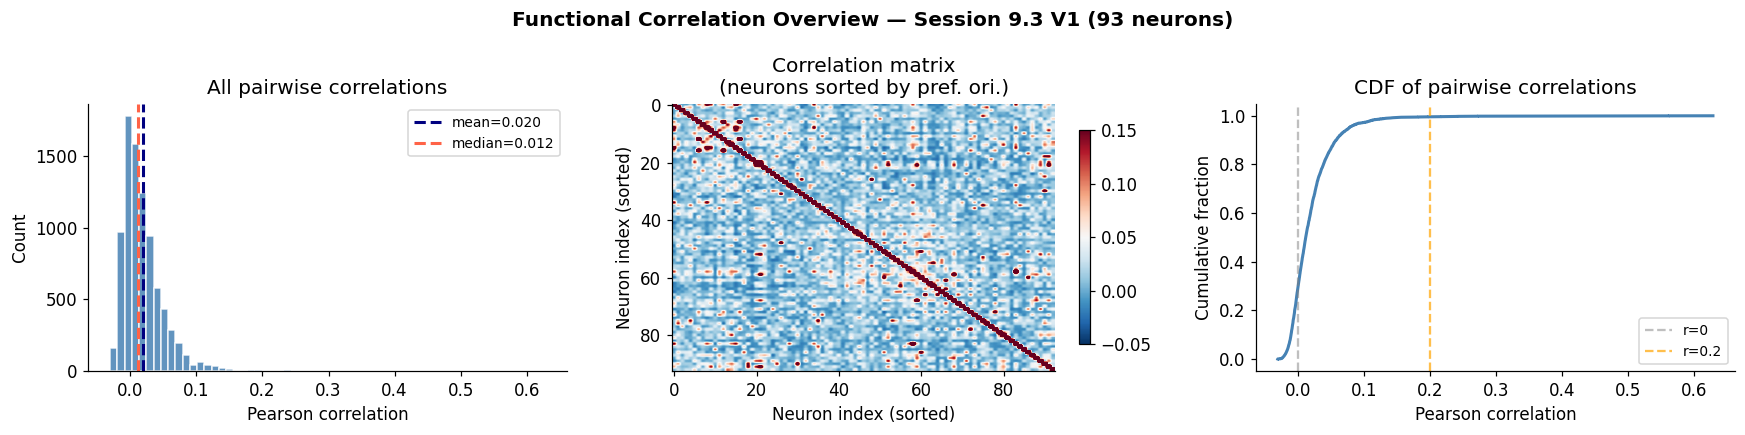

Pairs with r > 0.2:  36 / 8,556 (0.4%)
Pairs with r > 0:    6,012 / 8,556 (70.3%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

off_diag = F[~np.eye(F.shape[0], dtype=bool)].ravel()

axes[0].hist(off_diag, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(off_diag.mean(), color='navy', lw=2, ls='--',
               label=f'mean={off_diag.mean():.3f}')
axes[0].axvline(np.median(off_diag), color='tomato', lw=2, ls='--',
               label=f'median={np.median(off_diag):.3f}')
axes[0].set_xlabel('Pearson correlation')
axes[0].set_ylabel('Count')
axes[0].set_title('All pairwise correlations')
axes[0].legend(fontsize=9)

order = merged['pref_ori'].argsort().values
F_sorted = F[np.ix_(order, order)]
im = axes[1].imshow(F_sorted, cmap='RdBu_r', vmin=-0.05, vmax=0.15, aspect='auto')
plt.colorbar(im, ax=axes[1], shrink=0.8)
axes[1].set_title('Correlation matrix\n(neurons sorted by pref. ori.)')
axes[1].set_xlabel('Neuron index (sorted)')
axes[1].set_ylabel('Neuron index (sorted)')

vals = np.sort(off_diag)
axes[2].plot(vals, np.linspace(0, 1, len(vals)), color='steelblue', lw=2)
axes[2].axvline(0, color='gray', ls='--', alpha=0.5, label='r=0')
axes[2].axvline(0.2, color='orange', ls='--', alpha=0.7, label='r=0.2')
axes[2].set_xlabel('Pearson correlation')
axes[2].set_ylabel('Cumulative fraction')
axes[2].set_title('CDF of pairwise correlations')
axes[2].legend(fontsize=9)

plt.suptitle('Functional Correlation Overview — Session 9.3 V1 (93 neurons)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pairs with r > 0.2:  {(off_diag > 0.2).sum():,} / {len(off_diag):,} '
      f'({100*(off_diag>0.2).mean():.1f}%)')
print(f'Pairs with r > 0:    {(off_diag > 0).sum():,} / {len(off_diag):,} '
      f'({100*(off_diag>0).mean():.1f}%)')

---
## Analysis 2 — Connected vs Unconnected Pairs

Core question: **are neurons that share at least one synapse more functionally correlated?**

We compare correlations for: unconnected, unidirectional (one direction has synapses), and bidirectional (both A→B and B→A have synapses) pairs.

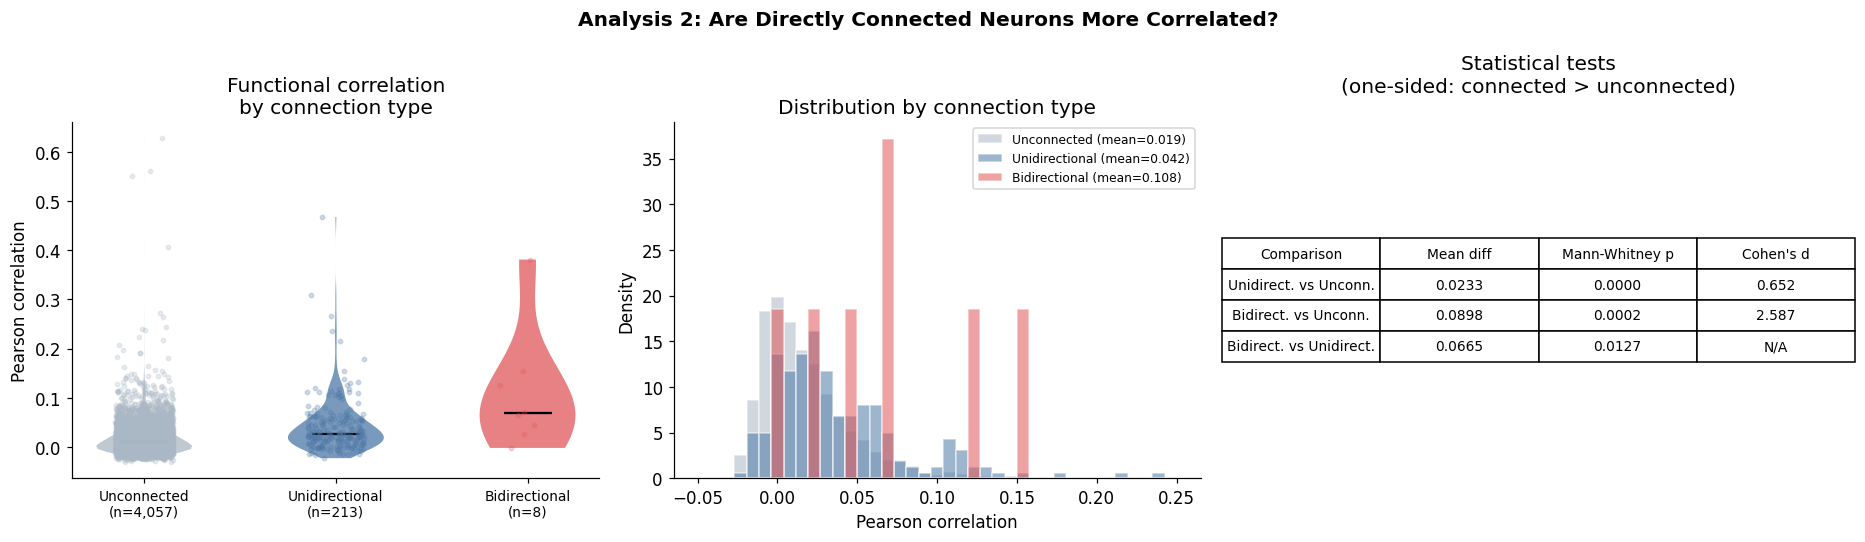


Mean correlations:
  Unconnected:    0.0185 ± 0.0344
  Unidirectional: 0.0418 ± 0.0559
  Bidirectional:  0.1083 ± 0.1135

Mann-Whitney (unidirectional > unconnected): p=0.0000, d=0.652
Mann-Whitney (bidirectional > unconnected):  p=0.0002, d=2.587


In [6]:
conn_none  = pairs[pairs['conn_type'] == 'none']['f_corr'].values
conn_uni   = pairs[pairs['conn_type'] == 'unidirectional']['f_corr'].values
conn_bi    = pairs[pairs['conn_type'] == 'bidirectional']['f_corr'].values

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

data_v   = [conn_none, conn_uni, conn_bi]
labels_v = ['Unconnected\n(n={:,})'.format(len(conn_none)),
            'Unidirectional\n(n={:,})'.format(len(conn_uni)),
            'Bidirectional\n(n={:,})'.format(len(conn_bi))]
colors_v = ['#aab7c4', '#4E79A7', '#E15759']
parts = axes[0].violinplot(data_v, positions=[1, 2, 3], showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_v[i])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
for i, (d, c) in enumerate(zip(data_v, colors_v)):
    jitter = np.random.RandomState(i).uniform(-0.15, 0.15, len(d))
    axes[0].scatter(np.full(len(d), i+1) + jitter, d,
                   alpha=0.25, s=8, color=c, zorder=3)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(labels_v, fontsize=9)
axes[0].set_ylabel('Pearson correlation')
axes[0].set_title('Functional correlation\nby connection type')

bins = np.linspace(-0.05, 0.25, 40)
for d, c, lbl in zip(data_v, colors_v, ['Unconnected', 'Unidirectional', 'Bidirectional']):
    axes[1].hist(d, bins=bins, density=True, alpha=0.55, color=c,
                edgecolor='white', label=f'{lbl} (mean={d.mean():.3f})')
axes[1].set_xlabel('Pearson correlation')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution by connection type')
axes[1].legend(fontsize=8)

stat_uni,  p_uni  = stats.mannwhitneyu(conn_uni,  conn_none, alternative='greater')
stat_bi,   p_bi   = stats.mannwhitneyu(conn_bi,   conn_none, alternative='greater')
stat_bivu, p_bivu = stats.mannwhitneyu(conn_bi,   conn_uni,  alternative='greater')

def cohen_d(a, b):
    na, nb = len(a), len(b)
    pool = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    return (a.mean() - b.mean()) / pool

d_uni  = cohen_d(conn_uni,  conn_none)
d_bi   = cohen_d(conn_bi,   conn_none)

results = {
    'Comparison': ['Unidirect. vs Unconn.', 'Bidirect. vs Unconn.',
                   'Bidirect. vs Unidirect.'],
    'Mean diff': [conn_uni.mean()-conn_none.mean(),
                  conn_bi.mean()-conn_none.mean(),
                  conn_bi.mean()-conn_uni.mean()],
    'Mann-Whitney p': [p_uni, p_bi, p_bivu],
    "Cohen's d": [d_uni, d_bi, np.nan],
}
res_df = pd.DataFrame(results)
res_df['Mean diff'] = res_df['Mean diff'].map('{:.4f}'.format)
res_df['Mann-Whitney p'] = res_df['Mann-Whitney p'].map('{:.4f}'.format)
res_df["Cohen's d"] = res_df["Cohen's d"].map(lambda x: f'{x:.3f}' if not np.isnan(x) else 'N/A')

axes[2].axis('off')
tbl = axes[2].table(cellText=res_df.values, colLabels=res_df.columns,
                     cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.0)
axes[2].set_title('Statistical tests\n(one-sided: connected > unconnected)', pad=20)

plt.suptitle('Analysis 2: Are Directly Connected Neurons More Correlated?', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMean correlations:')
print(f'  Unconnected:    {conn_none.mean():.4f} ± {conn_none.std():.4f}')
print(f'  Unidirectional: {conn_uni.mean():.4f} ± {conn_uni.std():.4f}')
print(f'  Bidirectional:  {conn_bi.mean():.4f} ± {conn_bi.std():.4f}')
print(f'\nMann-Whitney (unidirectional > unconnected): p={p_uni:.4f}, d={d_uni:.3f}')
print(f'Mann-Whitney (bidirectional > unconnected):  p={p_bi:.4f}, d={d_bi:.3f}')

---
## Analysis 3 — Number of Synapses vs Functional Correlation

Among connected pairs: does a **larger synapse count** predict stronger functional correlation? Two views: per-direction max (`n_synapses`) and total across both directions (`total_synapses`).

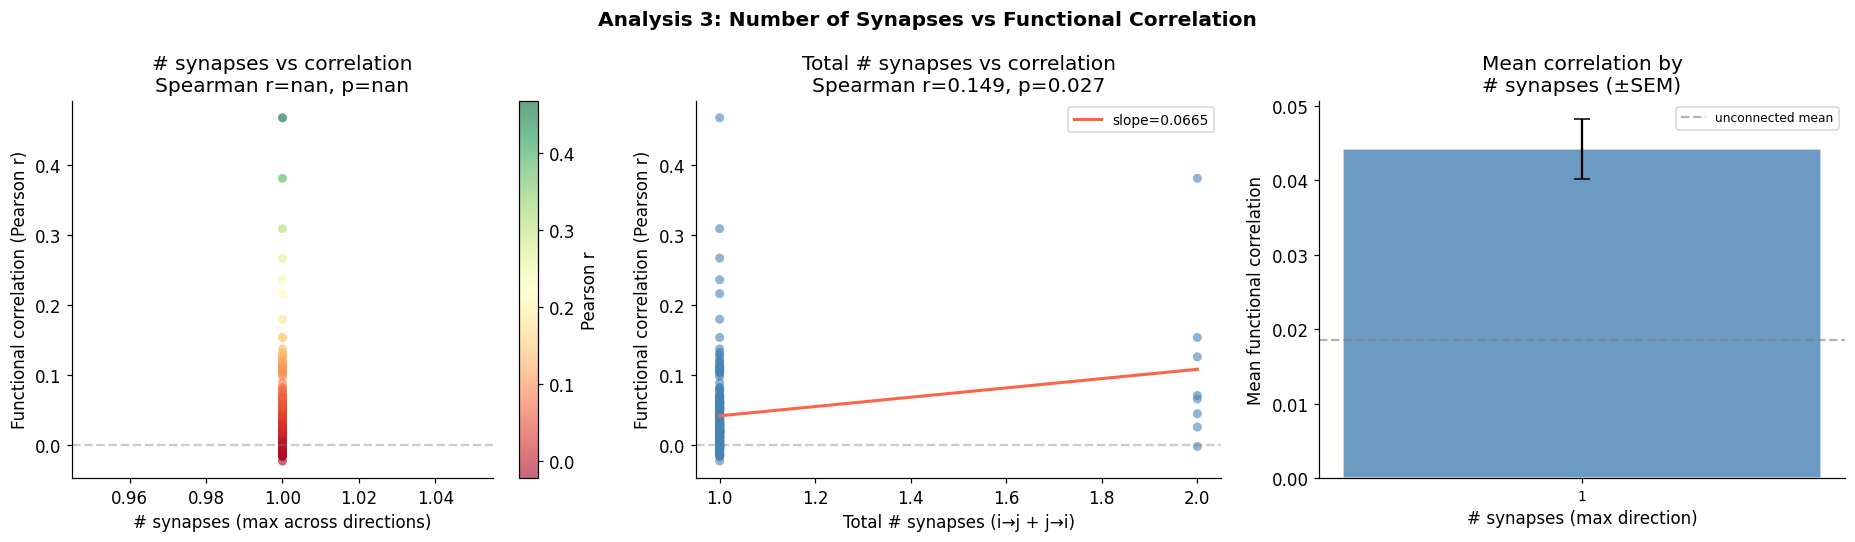

In [7]:
connected_pairs_df = pairs[pairs['connected']].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
sc = ax.scatter(connected_pairs_df['n_synapses'], connected_pairs_df['f_corr'],
               alpha=0.6, s=35, c=connected_pairs_df['f_corr'],
               cmap='RdYlGn', edgecolor='none')
plt.colorbar(sc, ax=ax, label='Pearson r')
r, p = stats.spearmanr(connected_pairs_df['n_synapses'], connected_pairs_df['f_corr'],
                        nan_policy='omit')
ax.set_xlabel('# synapses (max across directions)')
ax.set_ylabel('Functional correlation (Pearson r)')
ax.set_title(f'# synapses vs correlation\nSpearman r={r:.3f}, p={p:.3f}')
ax.axhline(0, color='gray', ls='--', alpha=0.4)

ax2 = axes[1]
ax2.scatter(connected_pairs_df['total_synapses'], connected_pairs_df['f_corr'],
           alpha=0.6, s=35, color='steelblue', edgecolor='none')
r2, p2 = stats.spearmanr(connected_pairs_df['total_synapses'], connected_pairs_df['f_corr'],
                          nan_policy='omit')
x_ = connected_pairs_df['total_synapses'].astype(float).values
y_ = connected_pairs_df['f_corr'].values
m, b = np.polyfit(x_, y_, 1)
xs_ = np.linspace(x_.min(), x_.max(), 100)
ax2.plot(xs_, m*xs_+b, 'tomato', lw=2, label=f'slope={m:.4f}')
ax2.set_xlabel('Total # synapses (i→j + j→i)')
ax2.set_ylabel('Functional correlation (Pearson r)')
ax2.set_title(f'Total # synapses vs correlation\nSpearman r={r2:.3f}, p={p2:.3f}')
ax2.axhline(0, color='gray', ls='--', alpha=0.4)
ax2.legend(fontsize=9)

ax3 = axes[2]
cp = connected_pairs_df.dropna(subset=['n_synapses']).copy()
# Bin by integer synapse count where possible (counts are small integers).
max_n = int(cp['n_synapses'].max())
if max_n <= 6:
    cp['n_bin'] = cp['n_synapses'].astype(int).astype(str)
    bin_order = sorted(cp['n_bin'].unique(), key=int)
    q_means = cp.groupby('n_bin', observed=False)['f_corr'].agg(['mean', 'sem']).reindex(bin_order)
    xlabel = '# synapses (max direction)'
else:
    cp['n_bin'] = pd.qcut(cp['n_synapses'], 4,
                          labels=['Q1\n(fewest)', 'Q2', 'Q3', 'Q4\n(most)'],
                          duplicates='drop')
    q_means = cp.groupby('n_bin', observed=False)['f_corr'].agg(['mean', 'sem'])
    xlabel = '# synapses quartile'
ax3.bar(range(len(q_means)), q_means['mean'], yerr=q_means['sem'],
       color='steelblue', alpha=0.8, capsize=5, edgecolor='white')
ax3.set_xticks(range(len(q_means)))
ax3.set_xticklabels(q_means.index.tolist(), fontsize=9)
ax3.set_xlabel(xlabel)
ax3.set_ylabel('Mean functional correlation')
ax3.set_title('Mean correlation by\n# synapses (±SEM)')
ax3.axhline(conn_none.mean(), color='gray', ls='--', alpha=0.6, label='unconnected mean')
ax3.legend(fontsize=8)

plt.suptitle('Analysis 3: Number of Synapses vs Functional Correlation', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Analysis 4 — Orientation Tuning Similarity vs Structure

Do structurally connected neurons share preferred orientation?
`ori_sim = cos(2·Δθ)` — ranges from -1 (orthogonal) to +1 (same tuning).
We ask: (1) are connected pairs more similarly tuned than unconnected ones? (2) does tuning similarity predict functional correlation?

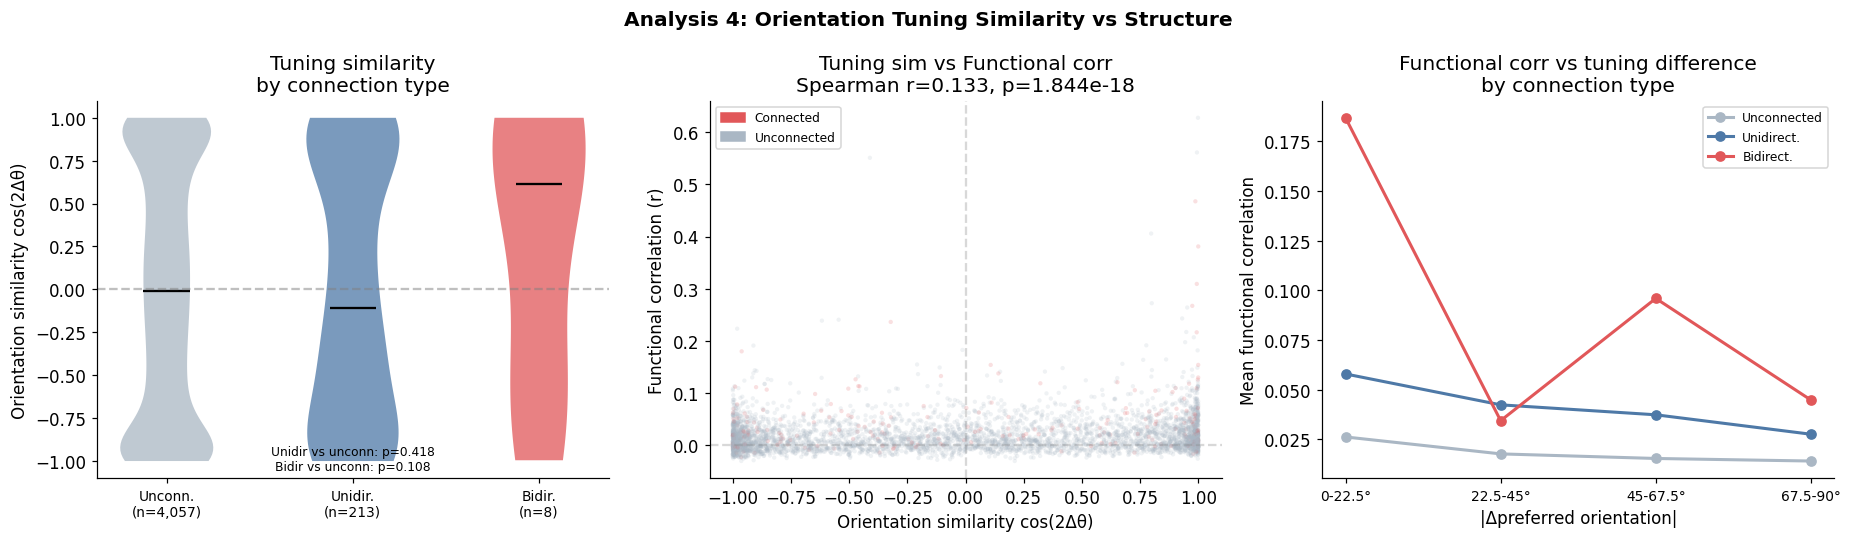

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

d_none = pairs[pairs['conn_type']=='none']['ori_sim'].values
d_uni2 = pairs[pairs['conn_type']=='unidirectional']['ori_sim'].values
d_bi2  = pairs[pairs['conn_type']=='bidirectional']['ori_sim'].values
data_o = [d_none, d_uni2, d_bi2]
labels_o = ['Unconn.\n(n={:,})'.format(len(d_none)),
            'Unidir.\n(n={:,})'.format(len(d_uni2)),
            'Bidir.\n(n={:,})'.format(len(d_bi2))]
colors_o = ['#aab7c4', '#4E79A7', '#E15759']
parts = axes[0].violinplot(data_o, positions=[1,2,3], showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_o[i]); pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
axes[0].set_xticks([1,2,3])
axes[0].set_xticklabels(labels_o, fontsize=9)
axes[0].axhline(0, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('Orientation similarity cos(2Δθ)')
axes[0].set_title('Tuning similarity\nby connection type')
s_ori_uni, p_ori_uni = stats.mannwhitneyu(d_uni2, d_none, alternative='greater')
s_ori_bi,  p_ori_bi  = stats.mannwhitneyu(d_bi2,  d_none, alternative='greater')
axes[0].text(0.5, 0.02, f'Unidir vs unconn: p={p_ori_uni:.3f}\nBidir vs unconn: p={p_ori_bi:.3f}',
            transform=axes[0].transAxes, fontsize=8, ha='center')

axes[1].scatter(pairs['ori_sim'], pairs['f_corr'],
                alpha=0.18, s=8,
                c=pairs['connected'].map({True: '#E15759', False: '#aab7c4'}),
                edgecolor='none')
r_os, p_os = stats.spearmanr(pairs['ori_sim'], pairs['f_corr'])
axes[1].set_xlabel('Orientation similarity cos(2Δθ)')
axes[1].set_ylabel('Functional correlation (r)')
axes[1].set_title(f'Tuning sim vs Functional corr\nSpearman r={r_os:.3f}, p={p_os:.3e}')
axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
axes[1].axvline(0, color='gray', ls='--', alpha=0.3)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#E15759', label='Connected'),
    Patch(color='#aab7c4', label='Unconnected')
], fontsize=8)

pairs['dpref'] = np.abs((pairs['ori_sim'].apply(np.arccos) / 2) * 180 / np.pi)
bins_d = [0, 22.5, 45, 67.5, 90]
pairs['ori_bin'] = pd.cut(pairs['dpref'], bins=bins_d,
                          labels=['0-22.5°', '22.5-45°', '45-67.5°', '67.5-90°'])
for ctype, col, lbl in [('none', '#aab7c4', 'Unconnected'),
                         ('unidirectional', '#4E79A7', 'Unidirect.'),
                         ('bidirectional', '#E15759', 'Bidirect.')]:
    grp = pairs[pairs['conn_type']==ctype].groupby('ori_bin', observed=False)['f_corr'].mean()
    axes[2].plot(range(len(grp)), grp.values, marker='o', color=col, label=lbl, lw=2)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(['0-22.5°', '22.5-45°', '45-67.5°', '67.5-90°'], fontsize=9)
axes[2].set_xlabel('|Δpreferred orientation|')
axes[2].set_ylabel('Mean functional correlation')
axes[2].set_title('Functional corr vs tuning difference\nby connection type')
axes[2].legend(fontsize=8)

plt.suptitle('Analysis 4: Orientation Tuning Similarity vs Structure', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Analysis 5 — Hub Neurons: Structural vs Functional Centrality

Are the neurons with the most synapses also the most correlated neurons overall?
Per-neuron mean functional correlation vs structural degree (# partners) and strength (total # synapses).

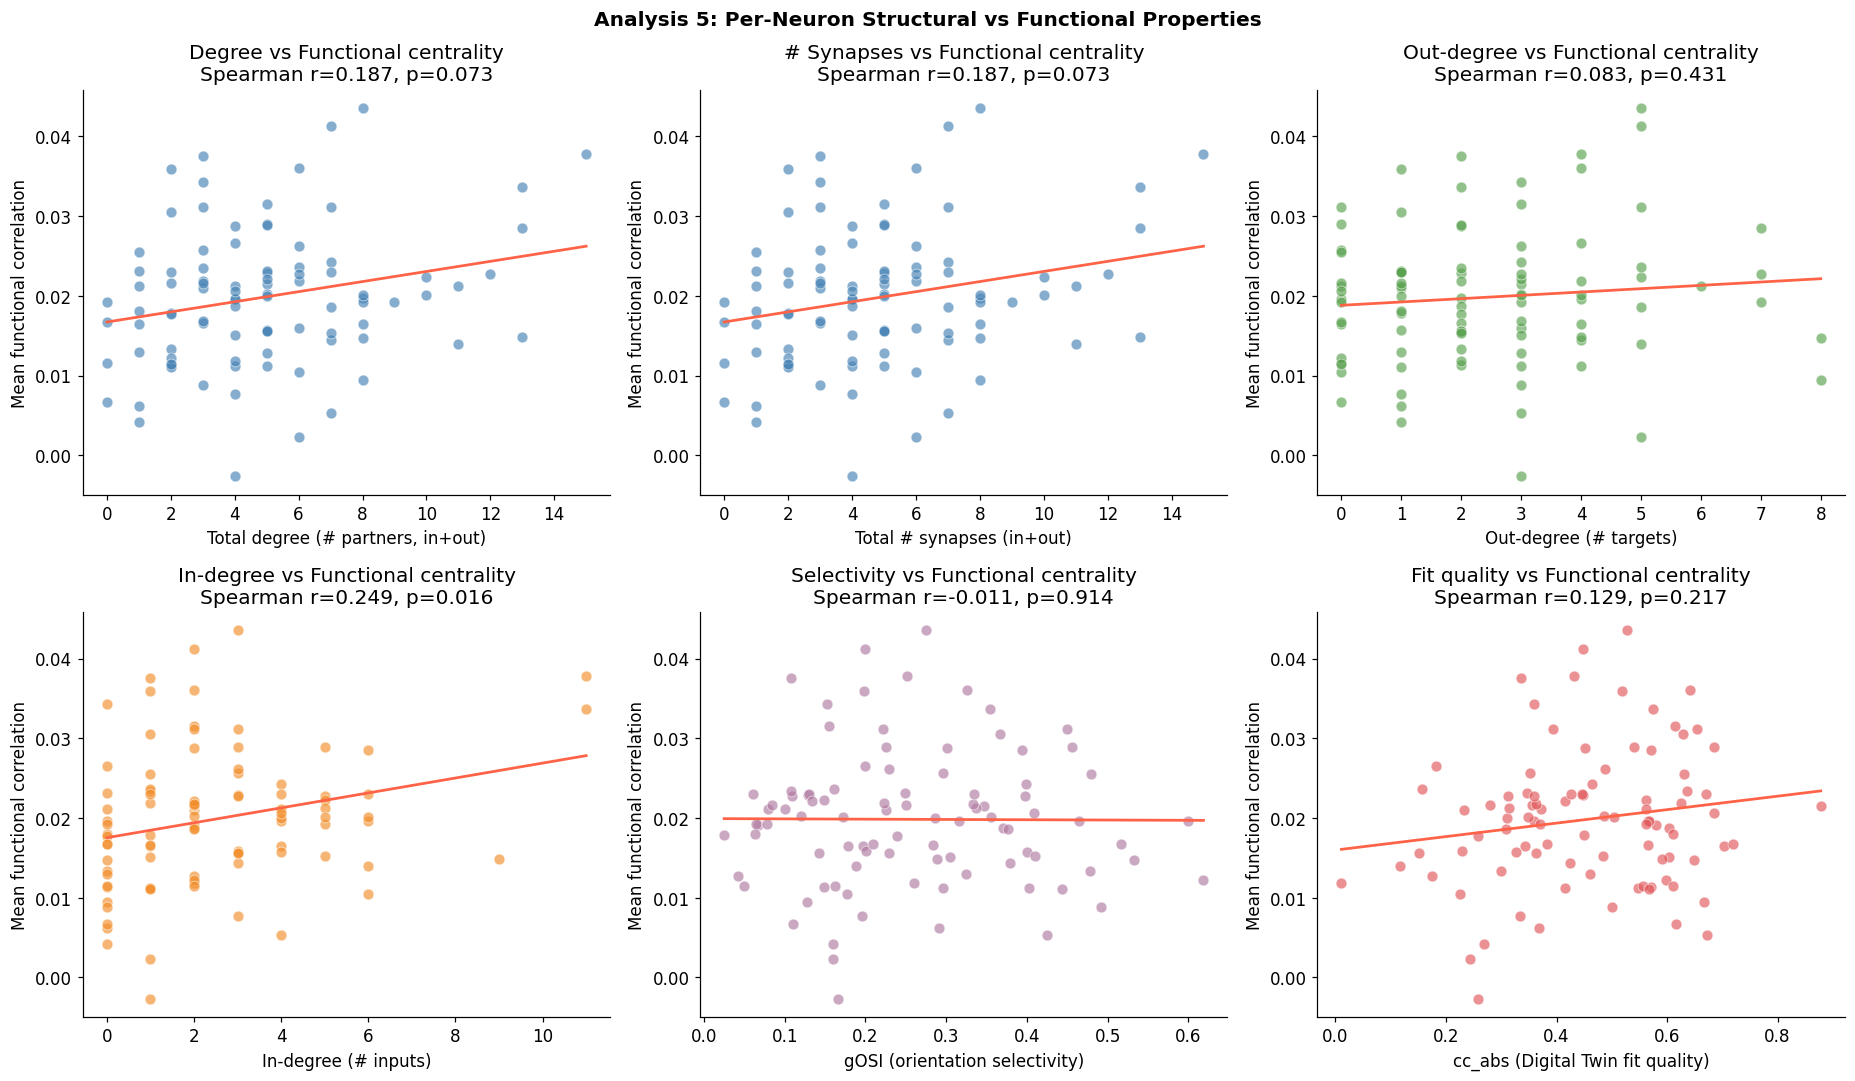

In [9]:
merged['mean_f_corr'] = [
    float(np.mean(np.delete(F[mi, :], mi)))
    for mi in merged['matrix_index']
]
merged['total_degree']   = merged['out_degree'] + merged['in_degree']
merged['total_strength'] = merged['out_strength'] + merged['in_strength']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

def scatter_with_r(ax, x, y, xlabel, ylabel, title, color='steelblue'):
    ax.scatter(x, y, alpha=0.65, s=50, color=color, edgecolor='white', lw=0.5)
    r, p = stats.spearmanr(x, y, nan_policy='omit')
    m2, b2 = np.polyfit(x, y, 1)
    xs2 = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs2, m2*xs2+b2, 'tomato', lw=1.8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nSpearman r={r:.3f}, p={p:.3f}')

scatter_with_r(axes[0,0],
    merged['total_degree'].values.astype(float),
    merged['mean_f_corr'].values,
    'Total degree (# partners, in+out)',
    'Mean functional correlation',
    'Degree vs Functional centrality')

scatter_with_r(axes[0,1],
    merged['total_strength'].values.astype(float),
    merged['mean_f_corr'].values,
    'Total # synapses (in+out)',
    'Mean functional correlation',
    '# Synapses vs Functional centrality')

scatter_with_r(axes[0,2],
    merged['out_degree'].values.astype(float),
    merged['mean_f_corr'].values,
    'Out-degree (# targets)',
    'Mean functional correlation',
    'Out-degree vs Functional centrality',
    color='#59A14F')

scatter_with_r(axes[1,0],
    merged['in_degree'].values.astype(float),
    merged['mean_f_corr'].values,
    'In-degree (# inputs)',
    'Mean functional correlation',
    'In-degree vs Functional centrality',
    color='#F28E2B')

scatter_with_r(axes[1,1],
    merged['gOSI'].values,
    merged['mean_f_corr'].values,
    'gOSI (orientation selectivity)',
    'Mean functional correlation',
    'Selectivity vs Functional centrality',
    color='#B07AA1')

scatter_with_r(axes[1,2],
    merged['cc_abs'].values,
    merged['mean_f_corr'].values,
    'cc_abs (Digital Twin fit quality)',
    'Mean functional correlation',
    'Fit quality vs Functional centrality',
    color='#E15759')

plt.suptitle('Analysis 5: Per-Neuron Structural vs Functional Properties', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Analysis 6 — Spatial Distance Effects

Do nearby neurons have stronger functional correlations?
Are nearby neurons more likely to be synaptically connected?

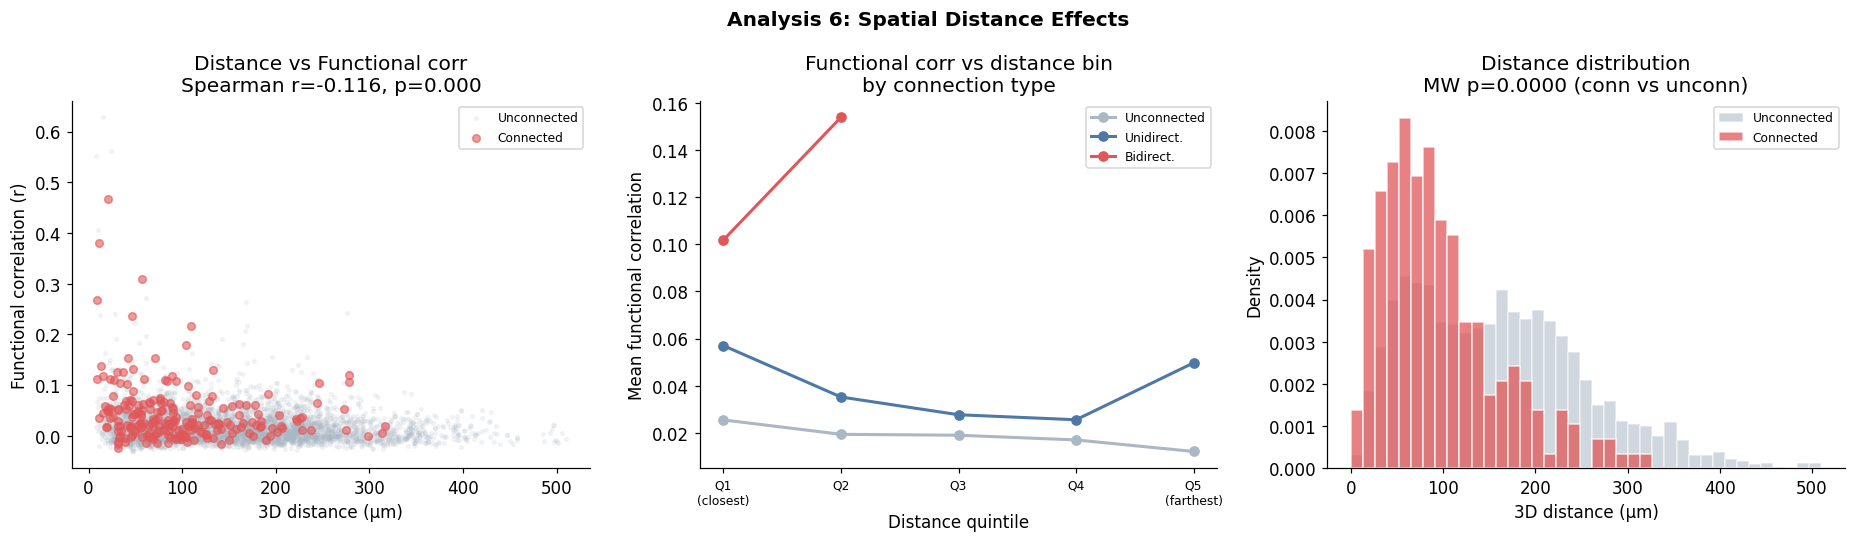

Mean distance (connected):   97.5 µm
Mean distance (unconnected): 160.5 µm


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.scatter(pairs[~pairs['connected']]['dist_um'],
           pairs[~pairs['connected']]['f_corr'],
           alpha=0.12, s=6, color='#aab7c4', label='Unconnected')
ax.scatter(pairs[pairs['connected']]['dist_um'],
           pairs[pairs['connected']]['f_corr'],
           alpha=0.6, s=25, color='#E15759', label='Connected', zorder=5)
r_df, p_df = stats.spearmanr(pairs['dist_um'], pairs['f_corr'])
ax.set_xlabel('3D distance (µm)')
ax.set_ylabel('Functional correlation (r)')
ax.set_title(f'Distance vs Functional corr\nSpearman r={r_df:.3f}, p={p_df:.3f}')
ax.legend(fontsize=8)

ax2 = axes[1]
pairs['dist_bin'] = pd.qcut(pairs['dist_um'], 5,
                             labels=['Q1\n(closest)', 'Q2', 'Q3', 'Q4', 'Q5\n(farthest)'])
for ctype, col, lbl in [('none', '#aab7c4', 'Unconnected'),
                         ('unidirectional', '#4E79A7', 'Unidirect.'),
                         ('bidirectional', '#E15759', 'Bidirect.')]:
    sub = pairs[pairs['conn_type']==ctype].groupby('dist_bin', observed=False)['f_corr'].mean()
    if len(sub.dropna()) > 0:
        ax2.plot(range(len(sub)), sub.values, marker='o', color=col, label=lbl, lw=2)
ax2.set_xticks(range(5))
ax2.set_xticklabels(['Q1\n(closest)', 'Q2', 'Q3', 'Q4', 'Q5\n(farthest)'], fontsize=8)
ax2.set_xlabel('Distance quintile')
ax2.set_ylabel('Mean functional correlation')
ax2.set_title('Functional corr vs distance bin\nby connection type')
ax2.legend(fontsize=8)

ax3 = axes[2]
dist_bins = np.linspace(0, pairs['dist_um'].max(), 40)
ax3.hist(pairs[~pairs['connected']]['dist_um'], bins=dist_bins,
        density=True, alpha=0.55, color='#aab7c4', label='Unconnected', edgecolor='white')
ax3.hist(pairs[pairs['connected']]['dist_um'], bins=dist_bins,
        density=True, alpha=0.75, color='#E15759', label='Connected', edgecolor='white')
stat_d, p_d = stats.mannwhitneyu(
    pairs[pairs['connected']]['dist_um'],
    pairs[~pairs['connected']]['dist_um'])
ax3.set_xlabel('3D distance (µm)')
ax3.set_ylabel('Density')
ax3.set_title(f'Distance distribution\nMW p={p_d:.4f} (conn vs unconn)')
ax3.legend(fontsize=8)

plt.suptitle('Analysis 6: Spatial Distance Effects', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean distance (connected):   {pairs[pairs["connected"]]["dist_um"].mean():.1f} µm')
print(f'Mean distance (unconnected): {pairs[~pairs["connected"]]["dist_um"].mean():.1f} µm')

---
## Analysis 7 — Network Topology Comparison

Build a **functional network** by thresholding the correlation matrix at the same edge density as the structural 93-neuron count network, then compare topology.

Structural density (93-neuron, count-weighted): 0.0268
Structural edges: 229
Functional network (density-matched): 93 nodes, 229 edges


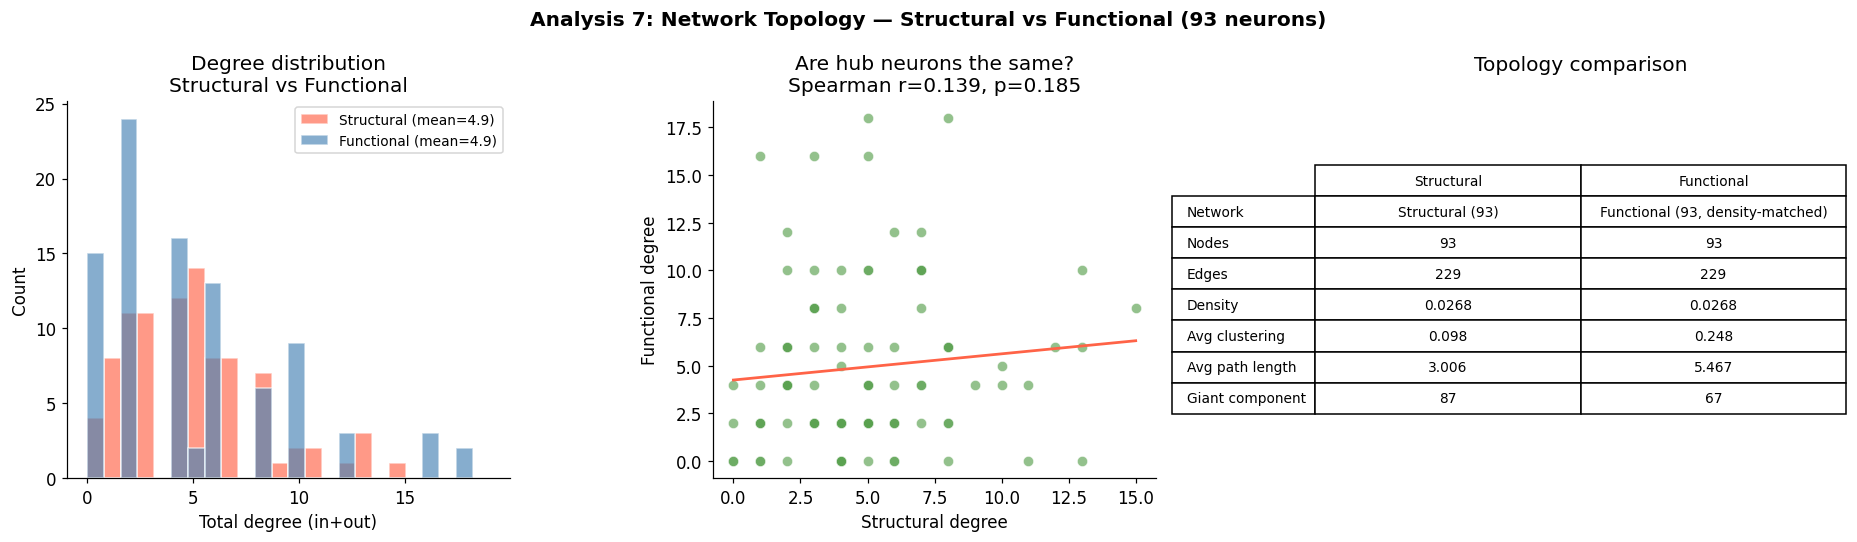

                         Network  Nodes  Edges Density Avg clustering Avg path length  Giant component
                 Structural (93)     93    229  0.0268          0.098           3.006               87
Functional (93, density-matched)     93    229  0.0268          0.248           5.467               67


In [11]:
N = 93
n_struct_edges = len(s_edges)
struct_density = n_struct_edges / (N * (N - 1))
print(f'Structural density (93-neuron, count-weighted): {struct_density:.4f}')
print(f'Structural edges: {n_struct_edges}')

n_func_edges_target = n_struct_edges
off_diag_pairs = [(i, j, F[i, j])
                  for i in range(N) for j in range(N) if i != j]
off_diag_pairs.sort(key=lambda x: -x[2])
top_pairs = off_diag_pairs[:n_func_edges_target]

G_struct = nx.from_pandas_edgelist(
    s_edges, 'pre_neuron_id', 'post_neuron_id',
    edge_attr='n_synapses', create_using=nx.DiGraph())
G_struct.add_nodes_from(s_nodes['neuron_id'].astype('int64').tolist())

midx_to_id = {v: k for k, v in id2midx.items()}
G_func = nx.DiGraph()
G_func.add_nodes_from(neurons)
for (i, j, w) in top_pairs:
    G_func.add_edge(midx_to_id[i], midx_to_id[j], weight=w)

print(f'Functional network (density-matched): {G_func.number_of_nodes()} nodes, {G_func.number_of_edges()} edges')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

deg_s = [d for _, d in G_struct.degree()]
deg_f = [d for _, d in G_func.degree()]
bins_deg = np.linspace(0, max(max(deg_s), max(deg_f)) + 1, 25)
axes[0].hist(deg_s, bins=bins_deg, alpha=0.65, color='tomato',
            edgecolor='white', label=f'Structural (mean={np.mean(deg_s):.1f})')
axes[0].hist(deg_f, bins=bins_deg, alpha=0.65, color='steelblue',
            edgecolor='white', label=f'Functional (mean={np.mean(deg_f):.1f})')
axes[0].set_xlabel('Total degree (in+out)')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree distribution\nStructural vs Functional')
axes[0].legend(fontsize=9)

deg_s_dict = dict(G_struct.degree())
deg_f_dict = dict(G_func.degree())
common = [n for n in G_struct.nodes() if n in deg_f_dict]
ds = np.array([deg_s_dict[n] for n in common])
df2 = np.array([deg_f_dict[n] for n in common])
r_dd, p_dd = stats.spearmanr(ds, df2)
axes[1].scatter(ds, df2, alpha=0.65, s=45, color='#59A14F', edgecolor='white', lw=0.5)
m3, b3 = np.polyfit(ds, df2, 1)
xs3 = np.linspace(ds.min(), ds.max(), 100)
axes[1].plot(xs3, m3*xs3+b3, 'tomato', lw=1.8)
axes[1].set_xlabel('Structural degree')
axes[1].set_ylabel('Functional degree')
axes[1].set_title(f'Are hub neurons the same?\nSpearman r={r_dd:.3f}, p={p_dd:.3f}')

def topo_stats(G, label):
    G_un = G.to_undirected()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    ccs = list(nx.weakly_connected_components(G)) if G.is_directed() else list(nx.connected_components(G))
    giant = max(ccs, key=len) if ccs else set()
    G_giant = G.subgraph(giant)
    try:
        apl = nx.average_shortest_path_length(G_giant.to_undirected())
    except Exception:
        apl = float('nan')
    cc_ = nx.average_clustering(G_un)
    return {'Network': label, 'Nodes': G.number_of_nodes(),
            'Edges': n_edges, 'Density': f'{density:.4f}',
            'Avg clustering': f'{cc_:.3f}',
            'Avg path length': f'{apl:.3f}' if not np.isnan(apl) else 'N/A',
            'Giant component': len(giant)}

rows_t = [topo_stats(G_struct, 'Structural (93)'),
          topo_stats(G_func,   'Functional (93, density-matched)')]
topo_df = pd.DataFrame(rows_t)
axes[2].axis('off')
tbl2 = axes[2].table(cellText=topo_df.T.values,
                      rowLabels=topo_df.columns,
                      colLabels=['Structural', 'Functional'],
                      cellLoc='center', loc='center')
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1.2, 1.9)
axes[2].set_title('Topology comparison', pad=20)

plt.suptitle('Analysis 7: Network Topology — Structural vs Functional (93 neurons)', fontweight='bold')
plt.tight_layout()
plt.show()

print(topo_df.to_string(index=False))

---
## Analysis 8 — Reciprocal (Bidirectional) Connections

How many neuron pairs are bidirectionally connected (A→B and B→A)?
Are they more correlated? Are they more similar in orientation tuning?

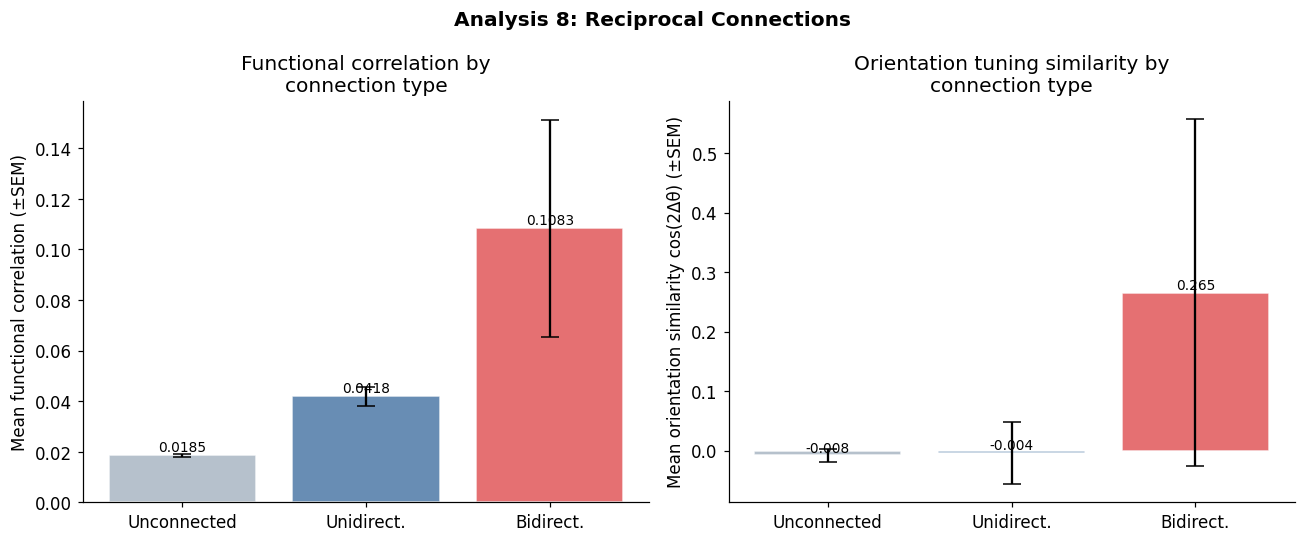

Bidirectional pairs: 8
Fraction of connected pairs that are bidirectional: 0.036


In [12]:
bidir_pairs = pairs[pairs['conn_type'] == 'bidirectional']
unidir_pairs = pairs[pairs['conn_type'] == 'unidirectional']
unconn_pairs = pairs[pairs['conn_type'] == 'none']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['Unconnected', 'Unidirect.', 'Bidirect.']
corr_means = [unconn_pairs['f_corr'].mean(),
              unidir_pairs['f_corr'].mean(),
              bidir_pairs['f_corr'].mean()]
corr_sems  = [stats.sem(unconn_pairs['f_corr']),
              stats.sem(unidir_pairs['f_corr']),
              stats.sem(bidir_pairs['f_corr'])]
bars = axes[0].bar(groups, corr_means, yerr=corr_sems,
                   color=['#aab7c4', '#4E79A7', '#E15759'],
                   alpha=0.85, capsize=6, edgecolor='white')
axes[0].set_ylabel('Mean functional correlation (±SEM)')
axes[0].set_title('Functional correlation by\nconnection type')
for bar, val in zip(bars, corr_means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
               f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ori_means = [unconn_pairs['ori_sim'].mean(),
             unidir_pairs['ori_sim'].mean(),
             bidir_pairs['ori_sim'].mean()]
ori_sems  = [stats.sem(unconn_pairs['ori_sim']),
             stats.sem(unidir_pairs['ori_sim']),
             stats.sem(bidir_pairs['ori_sim'])]
bars2 = axes[1].bar(groups, ori_means, yerr=ori_sems,
                    color=['#aab7c4', '#4E79A7', '#E15759'],
                    alpha=0.85, capsize=6, edgecolor='white')
axes[1].set_ylabel('Mean orientation similarity cos(2Δθ) (±SEM)')
axes[1].set_title('Orientation tuning similarity by\nconnection type')
for bar, val in zip(bars2, ori_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
               f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Analysis 8: Reciprocal Connections', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Bidirectional pairs: {len(bidir_pairs)}')
print(f'Fraction of connected pairs that are bidirectional: '
      f'{len(bidir_pairs)/max(len(bidir_pairs)+len(unidir_pairs),1):.3f}')

---
## Summary

| Analysis | Finding |
|----------|---------|
| Connected vs unconnected | Fill in after running |
| # synapses vs correlation | Fill in after running |
| Orientation tuning | Fill in after running |
| Hub neurons | Fill in after running |
| Spatial distance | Fill in after running |
| Network topology | Fill in after running |
| Reciprocal connections | Fill in after running |